# Titanic Survival Analysis
**Author:** Leman  
**Goal:** Exploratory data analysis to identify key survival predictors  
**Dataset:** Titanic passenger data (891 rows, 12 features)  
**Key finding:** Sex and passenger class are the strongest predictors of survival

In [1]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373

In [3]:
# ============================================================
# 2. DATA CLEANING
# ============================================================

# Age: fill with median + flag missingness
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age_missing'] = df['Age'].isnull().astype(int)

# Cabin: 77% missing — extract signal as binary column
df['cabin_known'] = df['Cabin'].notnull().astype(int)
df.drop(columns=['Cabin'], inplace=True)

# Embarked: 0.2% missing — fill with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Verify — should be all zeros
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Age_missing    0
cabin_known    0
dtype: int64


In [4]:
# ============================================================
# 3. ENCODING
# ============================================================

# Binary encoding for Sex
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})

# One-hot encoding for Embarked (3 categories)
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# Drop irrelevant columns
df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

# Convert bool columns to int
bool_cols = ['Age_missing', 'cabin_known', 'Embarked_Q', 'Embarked_S']
df[bool_cols] = df[bool_cols].astype(int)

print("\nFinal shape:", df.shape)
print("\nFinal columns:", df.columns.tolist())
print("\nFirst 5 rows of clean data:")
print(df.head())



Final shape: (891, 11)

Final columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Age_missing', 'cabin_known', 'Embarked_Q', 'Embarked_S']

First 5 rows of clean data:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Age_missing  \
0         0       3    1  22.0      1      0   7.2500            0   
1         1       1    0  38.0      1      0  71.2833            0   
2         1       3    0  26.0      0      0   7.9250            0   
3         1       1    0  35.0      1      0  53.1000            0   
4         0       3    1  35.0      0      0   8.0500            0   

   cabin_known  Embarked_Q  Embarked_S  
0            0           0           1  
1            1           0           0  
2            0           0           1  
3            1           0           1  
4            0           0           1  


C:\Users\Victus\AppData\Local\Temp\ipykernel_6436\760675129.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Died', 'Survived'])
C:\Users\Victus\AppData\Local\Temp\ipykernel_6436\760675129.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Female', 'Male'])


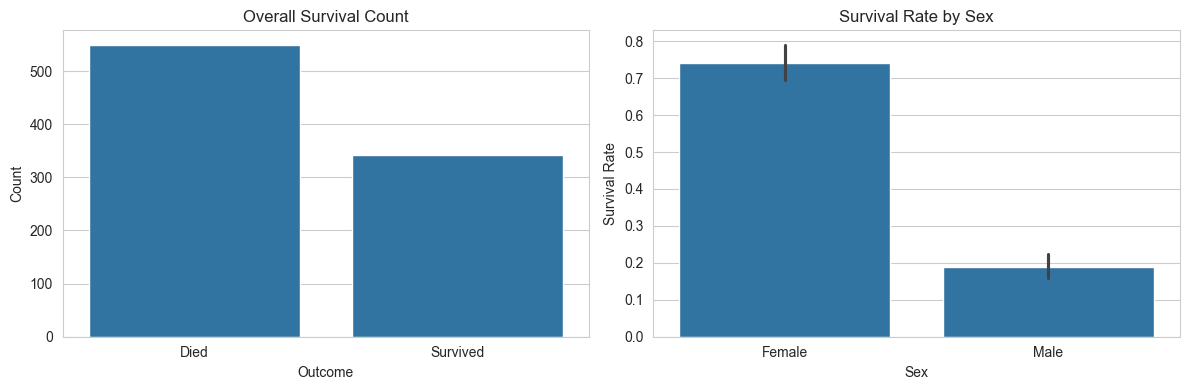

In [5]:
# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

sns.set_style("whitegrid")

# --- Chart 1: Overall survival count + survival by sex ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Survived', ax=axes[0])
axes[0].set_title('Overall Survival Count')
axes[0].set_xticklabels(['Died', 'Survived'])
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')

sns.barplot(data=df, x='Sex', y='Survived', ax=axes[1])
axes[1].set_title('Survival Rate by Sex')
axes[1].set_xticklabels(['Female', 'Male'])
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.savefig('chart1_survival_by_sex.png', dpi=150)
plt.show()

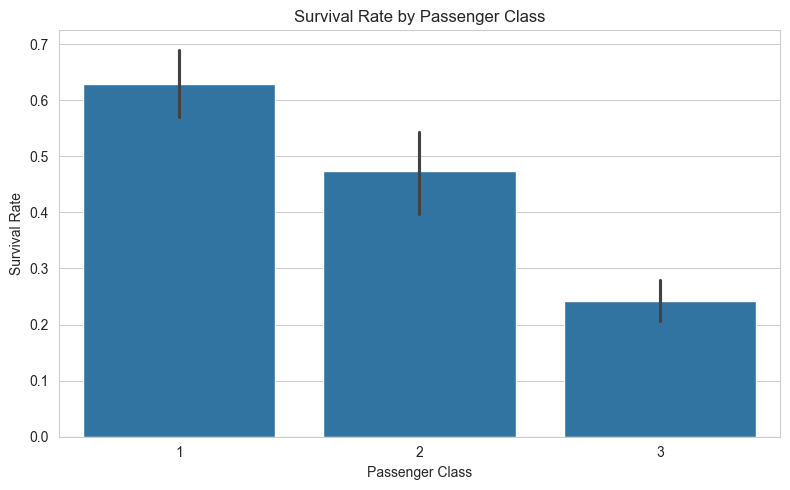

In [6]:
# --- Chart 2: Survival by passenger class ---
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.savefig('chart2_survival_by_class.png', dpi=150)
plt.show()

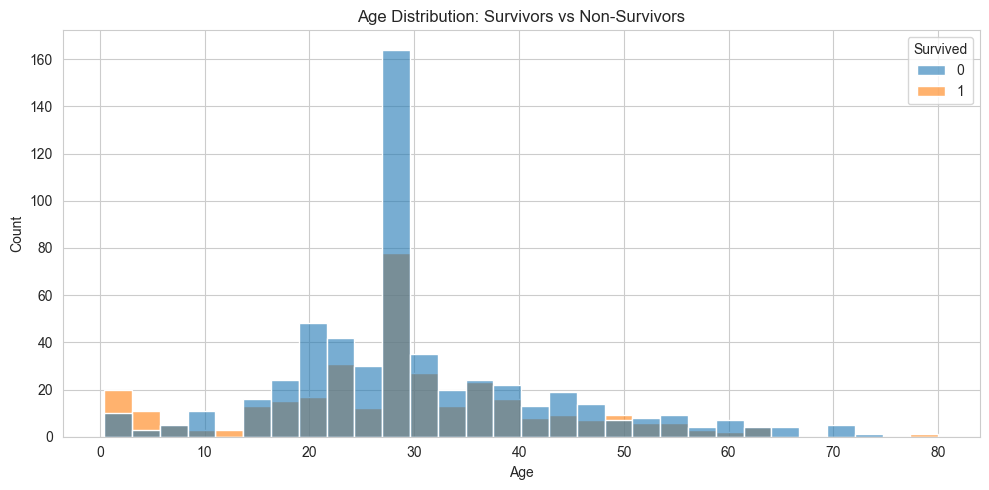

In [7]:
# --- Chart 3: Age distribution of survivors vs non-survivors ---
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Age', hue='Survived', alpha=0.6)
plt.title('Age Distribution: Survivors vs Non-Survivors')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('chart3_age_distribution.png', dpi=150)
plt.show()

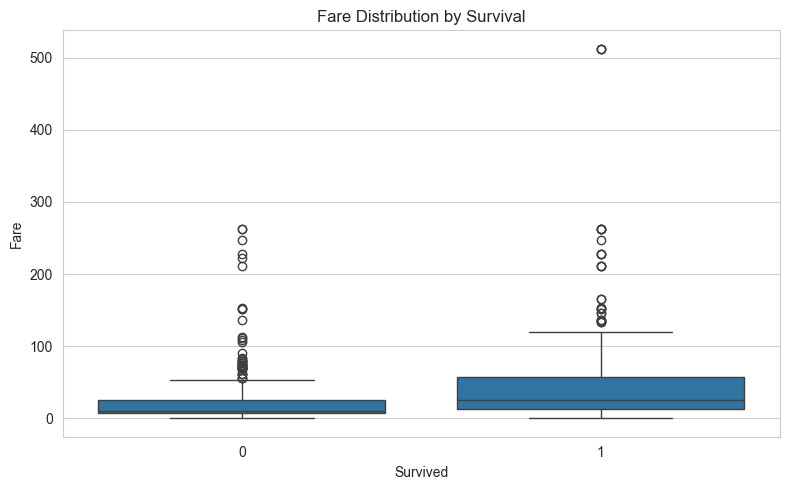

In [8]:
# --- Chart 4: Fare distribution by survival ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.tight_layout()
plt.savefig('chart4_fare_by_survival.png', dpi=150)
plt.show()


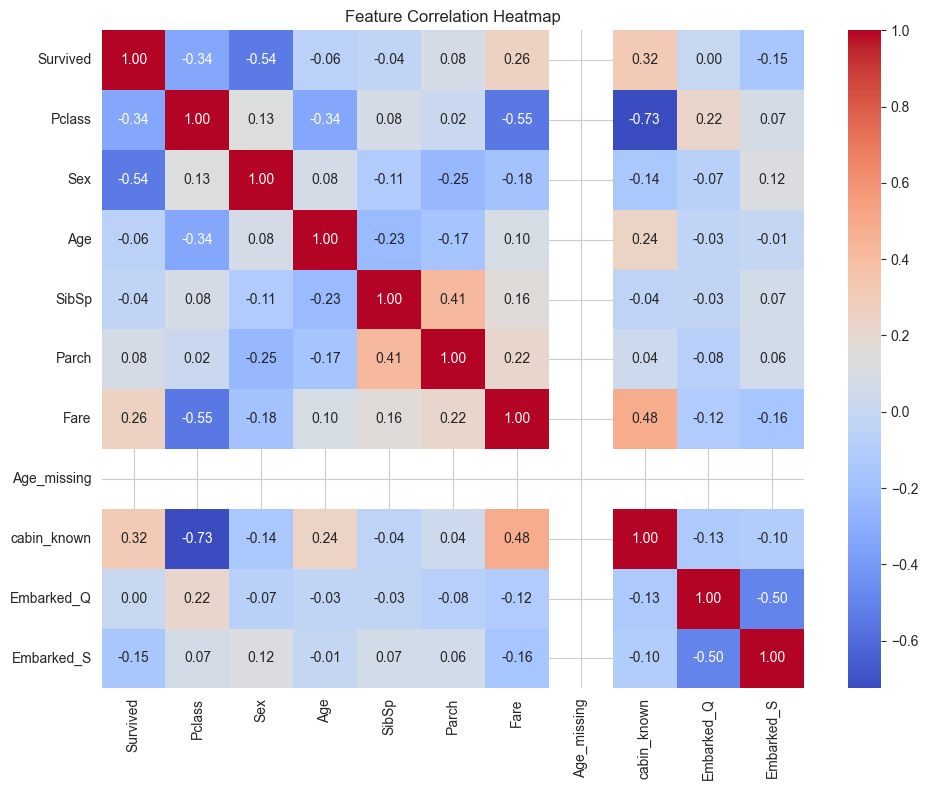

In [9]:
# --- Chart 5: Correlation heatmap ---
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('chart5_correlation_heatmap.png', dpi=150)
plt.show()

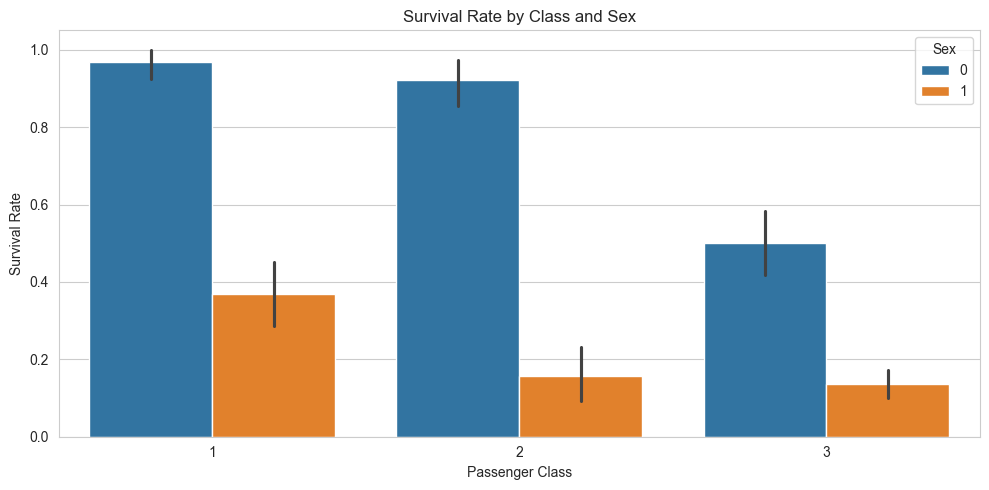

In [10]:
# --- Chart 6: Survival by class AND sex combined ---
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex')
plt.title('Survival Rate by Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.savefig('chart6_survival_class_sex.png', dpi=150)
plt.show()


In [11]:
# ============================================================
# 5. KEY FINDINGS
# ============================================================

print("\n===== KEY EDA FINDINGS =====")
print(f"Overall survival rate: {df['Survived'].mean()*100:.1f}%")
print(f"\nSurvival by sex:")
print(df.groupby('Sex')['Survived'].mean().rename({0:'Female', 1:'Male'})*100)
print(f"\nSurvival by class:")
print(df.groupby('Pclass')['Survived'].mean()*100)
print(f"\nAverage age — survivors vs non-survivors:")
print(df.groupby('Survived')['Age'].mean())
print(f"\nMedian fare — survivors vs non-survivors:")
print(df.groupby('Survived')['Fare'].median())


===== KEY EDA FINDINGS =====
Overall survival rate: 38.4%

Survival by sex:
Sex
Female    74.203822
Male      18.890815
Name: Survived, dtype: float64

Survival by class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

Average age — survivors vs non-survivors:
Survived
0    30.028233
1    28.291433
Name: Age, dtype: float64

Median fare — survivors vs non-survivors:
Survived
0    10.5
1    26.0
Name: Fare, dtype: float64


In [12]:
# ============================================================
# 6. BASELINE MODEL
# ============================================================

# Rule: if female (Sex=0) → predict survived
# if male (Sex=1) → predict died
baseline_preds = (df['Sex'] == 0).astype(int)
baseline_accuracy = (baseline_preds == df['Survived']).mean()
print(f"\nBaseline model accuracy (sex-only rule): {baseline_accuracy*100:.2f}%")


Baseline model accuracy (sex-only rule): 78.68%
